<a href="https://colab.research.google.com/github/LuisaTaho/neuroco-manejo-datos/blob/main/NeuroCo_EEG_DICOM_NIfTI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/LuisaTaho/neuroco-manejo-datos.git

Cloning into 'neuroco-manejo-datos'...
remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 11 (delta 1), reused 11 (delta 1), pack-reused 0 (from 0)
Receiving objects: 100% (11/11), 712.48 KiB | 7.34 MiB/s, done.
Resolving deltas: 100% (1/1), done.


# **Introducción al manejo de señales y neuroimágenes**

**Semillero Neurociencias Computacionales (NeuroCo)** - Autores: Luisa Fernanda Taho Mateus y Codex

Algunas de las preguntas que debemos hacernos al ver nuestros datos:

1. ¿Qué fenómeno fisiológico están representando estos datos?
2. ¿En qué unidades están los valores?
3. ¿Cómo se muestreó o adquirió el dato?
4. ¿Hay alguna información adicional, como información demográfica o baterías neuropsicológicas?



## Objetivos de aprendizaje

Al terminar podrán:

- distinguir escalar, vector, matriz, array y tensor;
- describir un dato mediante `shape`, `dtype`, ejes y unidades;
- reconocer frecuencia de muestreo, duración, amplitud y contenido espectral de una señal;
- cargar e inspeccionar un EEG con MNE;
- entender una serie DICOM y sus metadatos esenciales;
- convertir una serie DICOM a NIfTI (`.nii.gz`);
- visualizar cortes anatómicos y verificar la geometría del volumen.

### Convenciones de este notebook

- EEG en memoria: **canales × muestras**.
- Volumen: **x × y × z** (y quizá tiempo como cuarto eje).
- Las rutas se escriben con `pathlib.Path`, que funciona en Windows, macOS y Linux.
- Si no tienen datos reales, las secciones básicas funcionan con datos sintéticos.

**Entorno recomendado:** Python 3.11, 3.12 o 3.13 en un entorno virtual independiente.


In [1]:
# Si hace falta, descomenten y ejecuten UNA vez. Después reinicien el kernel.
%pip install -r /content/neuroco-manejo-datos/requirements.txt


In [3]:
#Solo si trabajan en Colab
%cd /content/neuroco-manejo-datos

/content/neuroco-manejo-datos


In [4]:
from pathlib import Path
import shutil
import subprocess
import sys

import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

np.set_printoptions(precision=3, suppress=True)
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True})

DATA_DIR = Path("datos")
OUTPUT_DIR = Path("resultados")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Python:", sys.version.split()[0])
print("Carpeta de trabajo:", Path.cwd().resolve())


Python: 3.12.13
Carpeta de trabajo: /content/neuroco-manejo-datos


# Canales en un montaje 10-20:
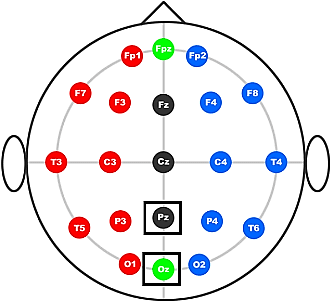

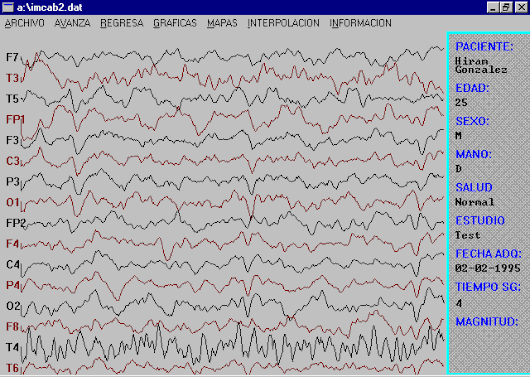

# 1. El lenguaje común: arrays y tensores

Un **array** es una colección rectangular de valores del mismo tipo. “Tensor” suele usarse como nombre general para un array de cualquier número de dimensiones, sobre todo en aprendizaje automático.

| Estructura | Dimensiones | Ejemplo neurocientífico |
|---|---:|---|
| Escalar | 0D | frecuencia de muestreo: 250 Hz |
| Vector | 1D | voltaje de un canal a lo largo del tiempo |
| Matriz | 2D | EEG: canales × muestras |
| Tensor 3D | 3D | RM: x × y × z |
| Tensor 4D | 4D | fMRI: x × y × z × tiempo |

La forma no explica por sí sola el dato: `(64, 1000)` podría ser canales × tiempo o tiempo × canales. Siempre documenten los **ejes** y las **unidades**.


In [5]:
escalar = np.array(250.0)
vector = np.arange(5)
matriz = np.arange(12).reshape(3, 4)
tensor_3d = np.zeros((64, 64, 32), dtype=np.float32)

for nombre, dato in {
    "escalar": escalar,
    "vector": vector,
    "matriz": matriz,
    "tensor_3d": tensor_3d,
}.items():
    print(f"{nombre:10s} shape={dato.shape!s:14s} ndim={dato.ndim} dtype={dato.dtype}")


escalar    shape=()             ndim=0 dtype=float64
vector     shape=(5,)           ndim=1 dtype=int64
matriz     shape=(3, 4)         ndim=2 dtype=int64
tensor_3d  shape=(64, 64, 32)   ndim=3 dtype=float32


In [6]:
# Indexar = seleccionar posiciones. Slicing = seleccionar intervalos.
print("Matriz completa:\n", matriz)
print("Fila 1:", matriz[1, :])
print("Columna 2:", matriz[:, 2])
print("Bloque filas 0:2, columnas 1:3:\n", matriz[0:2, 1:3])

# Cambiar el orden de ejes NO cambia los valores, pero sí su interpretación.
print("Original:", matriz.shape, "Transpuesta:", matriz.T.shape)


Matriz completa:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
Fila 1: [4 5 6 7]
Columna 2: [ 2  6 10]
Bloque filas 0:2, columnas 1:3:
 [[1 2]
 [5 6]]
Original: (3, 4) Transpuesta: (4, 3)


### Ver un array como imagen

Una matriz puede representarse como un mapa de color: cada celda conserva su posición y el color codifica el valor. Esto permite detectar patrones, bloques, valores extremos o ejes intercambiados.


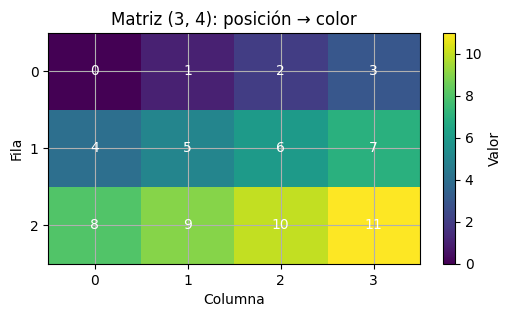

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
im = ax.imshow(matriz, cmap="viridis", aspect="auto")
ax.set(xlabel="Columna", ylabel="Fila", title=f"Matriz {matriz.shape}: posición → color")
ax.set_xticks(range(matriz.shape[1]))
ax.set_yticks(range(matriz.shape[0]))
for i in range(matriz.shape[0]):
    for j in range(matriz.shape[1]):
        ax.text(j, i, matriz[i, j], ha="center", va="center", color="white")
fig.colorbar(im, ax=ax, label="Valor")
plt.show()


### Lista de inspección universal

Para cualquier variable `x`, empiecen por:

```python
print(type(x))
print(x.shape, x.ndim, x.dtype)
print(np.nanmin(x), np.nanmax(x))
print(np.isnan(x).sum())
```

Pregunten además: ¿qué significa cada eje?, ¿qué unidad tiene?, ¿hay valores faltantes?, ¿el rango es plausible?, ¿cuánto ocupa en memoria?


In [8]:
def resumen_array(x, nombre="dato", ejes=None, unidades=None):
    # Resumen compacto sin modificar el dato.
    x = np.asarray(x)
    finitos = np.isfinite(x)
    print(f"{nombre}: shape={x.shape}, ndim={x.ndim}, dtype={x.dtype}")
    print(f"ejes={ejes}; unidades={unidades}; memoria={x.nbytes / 1024**2:.2f} MiB")
    print(f"finitos={finitos.sum()}/{x.size}; NaN={np.isnan(x).sum()}")
    if finitos.any():
        print(f"mín={x[finitos].min():.4g}; máx={x[finitos].max():.4g}; media={x[finitos].mean():.4g}")

resumen_array(tensor_3d, "volumen_demo", ("x", "y", "z"), "intensidad arbitraria")


volumen_demo: shape=(64, 64, 32), ndim=3, dtype=float32
ejes=('x', 'y', 'z'); unidades=intensidad arbitraria; memoria=0.50 MiB
finitos=131072/131072; NaN=0
mín=0; máx=0; media=0


## Mini-reto 1

Cree un tensor que represente 20 épocas EEG, 8 canales y 500 muestras.

1. ¿Cuál debe ser su `shape`?
2. Seleccione la época 3, todos los canales y las primeras 100 muestras.
3. Cambie el orden a canales × épocas × muestras con `np.transpose`.

<details><summary>Ver una solución</summary>

```python
epocas = np.zeros((20, 8, 500))
fragmento = epocas[2, :, :100]
reorganizado = np.transpose(epocas, (1, 0, 2))
```
</details>


# 2. Señales: amplitud que cambia con el tiempo

Una señal EEG digital es una secuencia de voltajes medidos en instantes discretos.

Conceptos indispensables:

- **Frecuencia de muestreo (`sfreq`)**: muestras por segundo, en Hz.
- **Periodo de muestreo**: `dt = 1 / sfreq`.
- **Duración**: `n_muestras / sfreq`.
- **Amplitud**: en MNE suele almacenarse en voltios; en artículos suele mostrarse en µV.
- **Frecuencia**: oscilaciones por segundo. Delta, theta, alfa, beta, etc. son bandas descriptivas, no diagnósticos automáticos.
- **Nyquist**: la frecuencia máxima representable es `sfreq / 2`.


In [9]:
rng = np.random.default_rng(42)
sfreq = 250.0  # Hz
duracion = 10.0  # s
tiempo = np.arange(0, duracion, 1 / sfreq)

# Dos canales en voltios: ritmo alfa + deriva + ruido.
eeg = np.vstack([
    25e-6 * np.sin(2 * np.pi * 10 * tiempo) + 8e-6 * np.sin(2 * np.pi * 1 * tiempo),
    18e-6 * np.sin(2 * np.pi * 12 * tiempo + 0.7),
])
eeg += rng.normal(scale=5e-6, size=eeg.shape)
nombres_canales = ["Fz", "Cz"]

resumen_array(eeg, "EEG sintético", ("canales", "muestras"), "V")
print(f"sfreq={sfreq} Hz; dt={1/sfreq:.4f} s; duración={eeg.shape[1]/sfreq:.2f} s; Nyquist={sfreq/2:.1f} Hz")


EEG sintético: shape=(2, 2500), ndim=2, dtype=float64
ejes=('canales', 'muestras'); unidades=V; memoria=0.04 MiB
finitos=5000/5000; NaN=0
mín=-4.493e-05; máx=4.252e-05; media=-9.939e-08
sfreq=250.0 Hz; dt=0.0040 s; duración=10.00 s; Nyquist=125.0 Hz


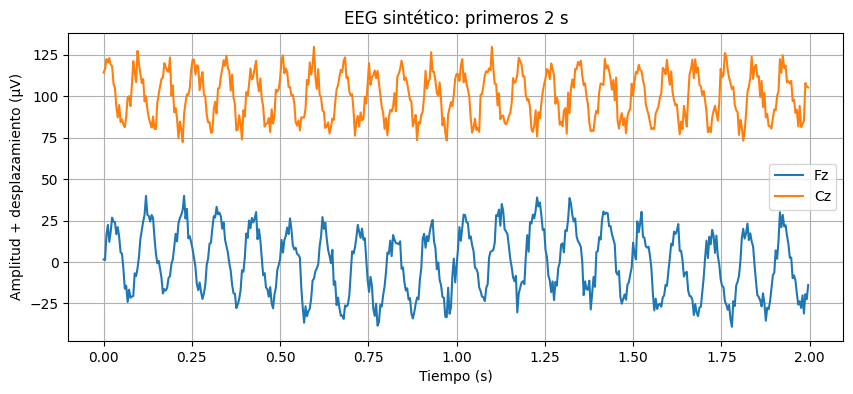

In [10]:
# Visualización temporal: convertir V → µV solo para mostrar.
ventana = tiempo < 2
fig, ax = plt.subplots()
desplazamiento = np.arange(eeg.shape[0])[:, None] * 100
ax.plot(tiempo[ventana], (eeg[:, ventana] * 1e6 + desplazamiento).T)
ax.set(xlabel="Tiempo (s)", ylabel="Amplitud + desplazamiento (µV)", title="EEG sintético: primeros 2 s")
ax.legend(nombres_canales)
plt.show()


### De una señal continua a muestras

El computador no almacena una curva continua: almacena valores separados por `dt`. Al aumentar `sfreq` hay más puntos por segundo; no aparece información nueva si el sistema de adquisición no la midió correctamente.


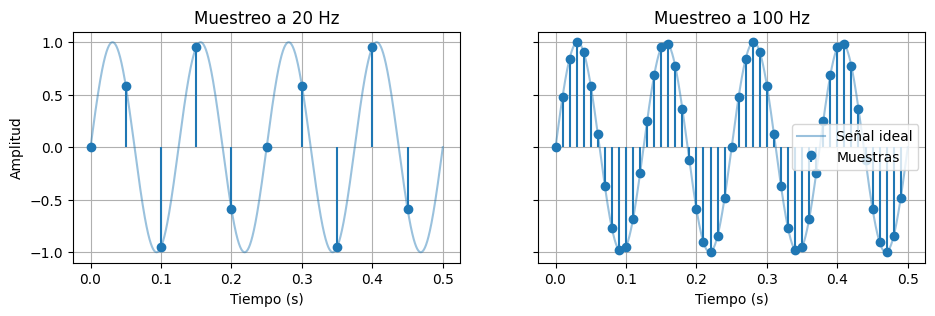

In [11]:
t_continuo = np.linspace(0, 0.5, 2000)
fig, axes = plt.subplots(1, 2, figsize=(11, 3), sharey=True)
for ax, fs_demo in zip(axes, [20, 100]):
    t_muestra = np.arange(0, 0.5, 1 / fs_demo)
    ax.plot(t_continuo, np.sin(2 * np.pi * 8 * t_continuo), alpha=0.45, label="Señal ideal")
    ax.stem(t_muestra, np.sin(2 * np.pi * 8 * t_muestra), basefmt=" ", label="Muestras")
    ax.set(title=f"Muestreo a {fs_demo} Hz", xlabel="Tiempo (s)")
axes[0].set_ylabel("Amplitud")
axes[1].legend()
plt.show()


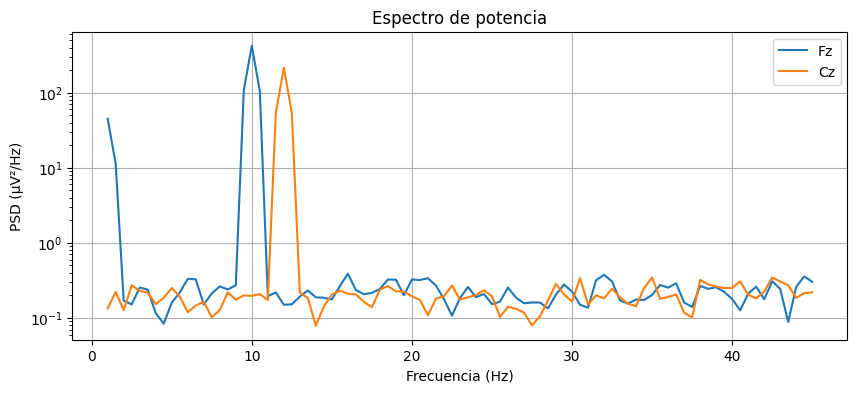

In [12]:
# Densidad espectral de potencia (Welch): ¿en qué frecuencias hay energía?
freqs, psd = signal.welch(eeg, fs=sfreq, nperseg=int(2 * sfreq), axis=-1)
banda = (freqs >= 1) & (freqs <= 45)

fig, ax = plt.subplots()
for canal, nombre in enumerate(nombres_canales):
    ax.semilogy(freqs[banda], psd[canal, banda] * 1e12, label=nombre)
ax.set(xlabel="Frecuencia (Hz)", ylabel="PSD (µV²/Hz)", title="Espectro de potencia")
ax.legend()
plt.show()


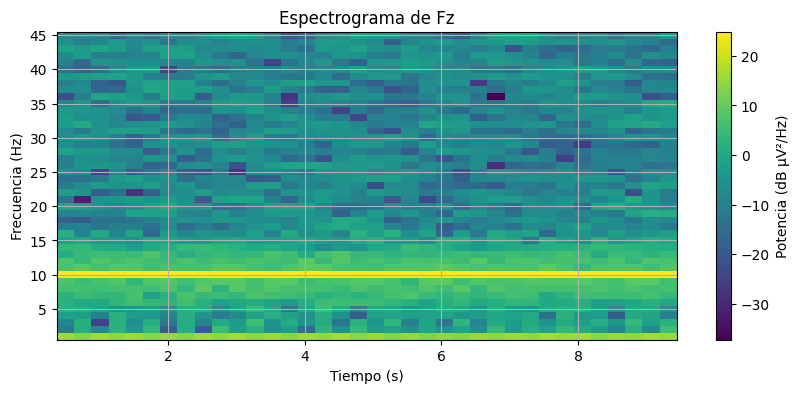

In [13]:
# El espectrograma agrega el eje tiempo: muestra cómo cambia el espectro.
f_spec, t_spec, sxx = signal.spectrogram(
    eeg[0], fs=sfreq, nperseg=int(sfreq), noverlap=int(0.75 * sfreq)
)
visible = (f_spec >= 1) & (f_spec <= 45)
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.pcolormesh(t_spec, f_spec[visible], 10 * np.log10(sxx[visible] * 1e12 + 1e-20), shading="auto")
ax.set(xlabel="Tiempo (s)", ylabel="Frecuencia (Hz)", title="Espectrograma de Fz")
fig.colorbar(im, ax=ax, label="Potencia (dB µV²/Hz)")
plt.show()


/tmp/ipykernel_2724/2001901351.py:4: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  nombre: np.trapz(psd[:, (freqs >= f0) & (freqs < f1)], freqs[(freqs >= f0) & (freqs < f1)], axis=1) * 1e12


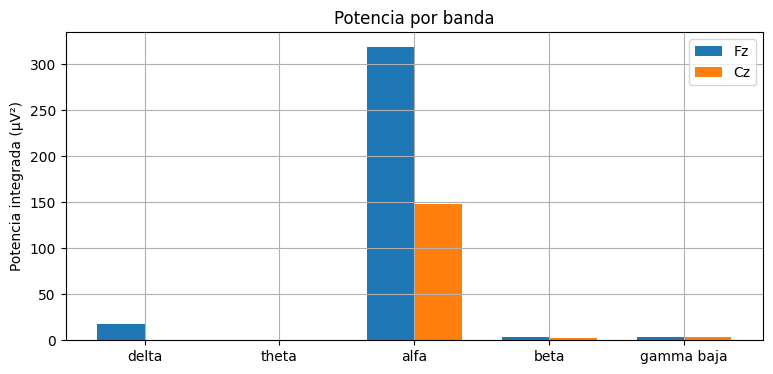

In [14]:
# Resumir el espectro por bandas (descriptivo, no diagnóstico).
bandas = {"delta": (1, 4), "theta": (4, 8), "alfa": (8, 13), "beta": (13, 30), "gamma baja": (30, 45)}
potencia_bandas = {
    nombre: np.trapz(psd[:, (freqs >= f0) & (freqs < f1)], freqs[(freqs >= f0) & (freqs < f1)], axis=1) * 1e12
    for nombre, (f0, f1) in bandas.items()
}

x = np.arange(len(bandas))
fig, ax = plt.subplots(figsize=(9, 4))
ancho = 0.35
for canal, nombre_canal in enumerate(nombres_canales):
    ax.bar(x + (canal - 0.5) * ancho, [v[canal] for v in potencia_bandas.values()], ancho, label=nombre_canal)
ax.set_xticks(x, bandas.keys())
ax.set(ylabel="Potencia integrada (µV²)", title="Potencia por banda")
ax.legend()
plt.show()


### Aliasing y filtrado: dos advertencias

- Una señal por encima de Nyquist puede “disfrazarse” como una frecuencia menor (**aliasing**). El antialiasing debe ocurrir antes de digitalizar o remuestrear.
- Un filtro modifica la señal. Registren tipo, frecuencias de corte, orden y fase; comparen siempre antes/después y eviten elegir parámetros solo porque la gráfica “se ve bonita”.

La línea eléctrica suele aparecer cerca de 50 o 60 Hz según el país y la instalación. No supongan: inspeccionen el espectro.


# 3. Cargar un EEG real con MNE

[MNE-Python](https://mne.tools/) representa registros continuos con un objeto `Raw`:

- `raw.get_data()`: array canales × muestras;
- `raw.info`: frecuencia, nombres/tipos de canal, filtros, dispositivo y más;
- `raw.annotations`: eventos o intervalos anotados;
- `raw.times`: vector temporal.

MNE usa **voltios** para EEG internamente. Si un CSV está en µV, dividan entre `1e6` al crear `RawArray`.


In [15]:
import mne

# Demo ejecutable: envolver el array sintético en la estructura de MNE.
info = mne.create_info(nombres_canales, sfreq=sfreq, ch_types="eeg")
raw_demo = mne.io.RawArray(eeg, info, verbose=False)
raw_demo.set_montage("standard_1020", on_missing="warn")

print(raw_demo)
print("Forma:", raw_demo.get_data().shape)
print("Frecuencia:", raw_demo.info["sfreq"], "Hz")
print("Canales:", raw_demo.ch_names)
print("Duración:", raw_demo.times[-1], "s")


<RawArray | 2 x 2500 (10.0 s), ~47 KiB, data loaded>
Forma: (2, 2500)
Frecuencia: 250.0 Hz
Canales: ['Fz', 'Cz']
Duración: 9.996 s


In [20]:
# Cambien la ruta y dejen SOLO la línea correspondiente al formato real.
ruta_eeg = Path("/content/neuroco-manejo-datos/datos/ejemplo_eegbci/S001R01.edf")

if ruta_eeg.exists():
    sufijo = ruta_eeg.suffix.lower()
    if sufijo == ".edf":
        raw = mne.io.read_raw_edf(ruta_eeg, preload=False)
    elif sufijo == ".bdf":
        raw = mne.io.read_raw_bdf(ruta_eeg, preload=False)
    elif sufijo == ".fif":
        raw = mne.io.read_raw_fif(ruta_eeg, preload=False)
    elif sufijo == ".vhdr":
        raw = mne.io.read_raw_brainvision(ruta_eeg, preload=False)
    else:
        raise ValueError(f"Formato no configurado: {sufijo}")
else:
    raw = raw_demo
    print(f"No existe {ruta_eeg}; se usa el EEG sintético.")

print(raw)


Extracting EDF parameters from /content/neuroco-manejo-datos/datos/ejemplo_eegbci/S001R01.edf...
Setting channel info structure...
Creating raw.info structure...
<RawEDF | S001R01.edf, 64 x 9760 (61.0 s), ~52 KiB, data not loaded>


In [21]:
def auditar_raw(raw):
    datos = raw.get_data()
    print("shape (canales, muestras):", datos.shape)
    print("sfreq:", raw.info["sfreq"], "Hz")
    print("duración:", raw.n_times / raw.info["sfreq"], "s")
    print("tipos:", raw.get_channel_types())
    print("canales malos:", raw.info["bads"])
    print("anotaciones:", len(raw.annotations))
    print("rango EEG:", datos.min() * 1e6, "a", datos.max() * 1e6, "µV")
    return datos

datos_eeg = auditar_raw(raw)


shape (canales, muestras): (64, 9760)
sfreq: 160.0 Hz
duración: 61.0 s
tipos: ['eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg', 'eeg']
canales malos: []
anotaciones: 1
rango EEG: -518.0 a 597.0 µV


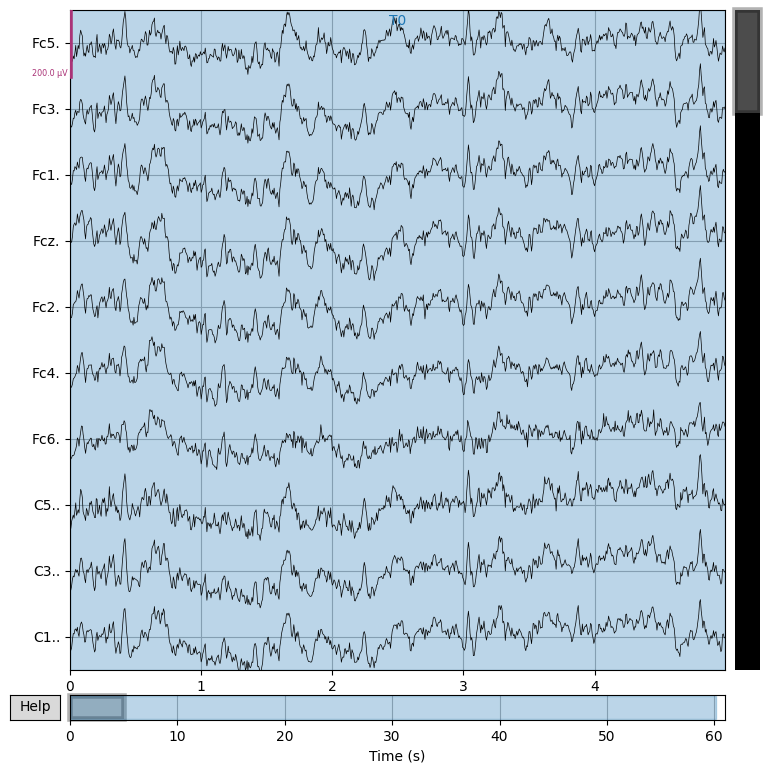

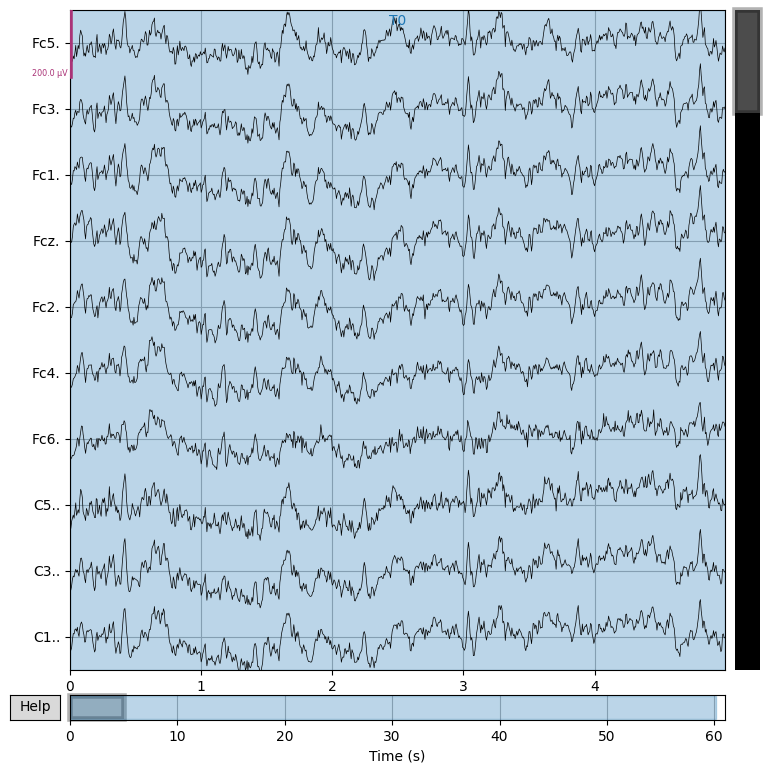

In [24]:
raw.plot(
    duration=5,
    n_channels=10,
    scalings={"eeg": 100e-6},
    show=True
)

## Señal pública opcional: EEGBCI de PhysioNet

Este proyecto ya incluye el sujeto 1, corrida 1, del conjunto EEG Motor Movement/Imagery de PhysioNet: un minuto de reposo con ojos abiertos, 64 canales, 160 Hz y formato EDF+. Si el archivo local no está, MNE puede descargarlo al cambiar el interruptor a `True`.

Para paradigmas de movimiento o imaginación motora, consulten el significado de las corridas y de las anotaciones antes de asignar etiquetas. No conviertan códigos de evento en clases por intuición.


In [ ]:
RUTA_EEGBCI_LOCAL = DATA_DIR / "ejemplo_eegbci" / "S001R01.edf"
DESCARGAR_EEGBCI = False  # Solo se usa si falta el archivo incluido.
raw_abierto = None

from mne.datasets import eegbci
if RUTA_EEGBCI_LOCAL.exists():
    ruta_abierta = RUTA_EEGBCI_LOCAL
    print("Usando archivo público incluido:", ruta_abierta.resolve())
elif DESCARGAR_EEGBCI:
    rutas = eegbci.load_data(
        1,
        [1],
        path=DATA_DIR / "mne_data",
        update_path=False,
    )
    ruta_abierta = rutas[0]
else:
    ruta_abierta = None
    print("No está el EDF local y la descarga está desactivada.")

if ruta_abierta is not None:
    raw_abierto = mne.io.read_raw_edf(ruta_abierta, preload=True, verbose=False)
    eegbci.standardize(raw_abierto)
    raw_abierto.set_montage("standard_1005", on_missing="warn")
    print(raw_abierto)


In [ ]:
# Gráficas de control de calidad para el EEG abierto (si fue descargado).
if raw_abierto is not None:
    segmento = raw_abierto.get_data(picks="eeg", start=0, stop=int(5 * raw_abierto.info["sfreq"])) * 1e6

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    im = axes[0].imshow(segmento, aspect="auto", cmap="RdBu_r", vmin=-100, vmax=100,
                        extent=[0, 5, segmento.shape[0], 0])
    axes[0].set(xlabel="Tiempo (s)", ylabel="Canal", title="EEG: canales × tiempo")
    fig.colorbar(im, ax=axes[0], label="µV")

    rms = np.sqrt(np.mean(segmento**2, axis=1))
    axes[1].barh(np.arange(len(rms)), rms)
    axes[1].invert_yaxis()
    axes[1].set(xlabel="RMS (µV)", ylabel="Canal", title="Amplitud RMS por canal")
    plt.tight_layout()
    plt.show()

    raw_abierto.plot_sensors(show_names=False, sphere="auto")
else:
    print("Ejecute primero la descarga opcional para generar estas gráficas.")


### Si el EEG viene en CSV

CSV no conserva un estándar universal: primero averigüen si las filas son tiempo o canales, cuál columna es tiempo y si la amplitud está en V, mV o µV.

```python
import pandas as pd
tabla = pd.read_csv("datos/eeg.csv")
print(tabla.head(), tabla.dtypes, tabla.shape)

nombres = ["Fz", "Cz", "Pz"]
datos_uv = tabla[nombres].to_numpy().T       # canales × muestras
datos_v = datos_uv * 1e-6                    # µV → V
info = mne.create_info(nombres, sfreq=250, ch_types="eeg")
raw_csv = mne.io.RawArray(datos_v, info)
```

Nunca infieran `sfreq` únicamente del número de filas. Debe venir del protocolo o calcularse de una columna temporal confiable.


## Mini-reto 2

Con un registro de su proyecto, respondan:

1. ¿Cuántos canales y muestras tiene?
2. ¿Cuál es su duración y frecuencia de Nyquist?
3. ¿Qué canales no son EEG (EOG, ECG, estímulo)?
4. ¿Hay anotaciones, canales malos o posiciones faltantes?
5. ¿El rango de amplitud es plausible al convertirlo a µV?
6. ¿Dónde aparecen los picos principales del espectro?


# 4. Imágenes médicas: píxeles, vóxeles y coordenadas

- Un **píxel** ocupa una posición en una imagen 2D.
- Un **vóxel** ocupa una celda en un volumen 3D.
- El valor del vóxel no es una coordenada: es una intensidad (y su significado depende de la modalidad y del procesamiento).
- El tamaño del array indica cuántos vóxeles hay; el **espaciado** indica su tamaño físico, normalmente en mm.

Dos cerebros con arrays `(256, 256, 160)` pueden no ocupar el mismo espacio físico ni estar orientados igual.


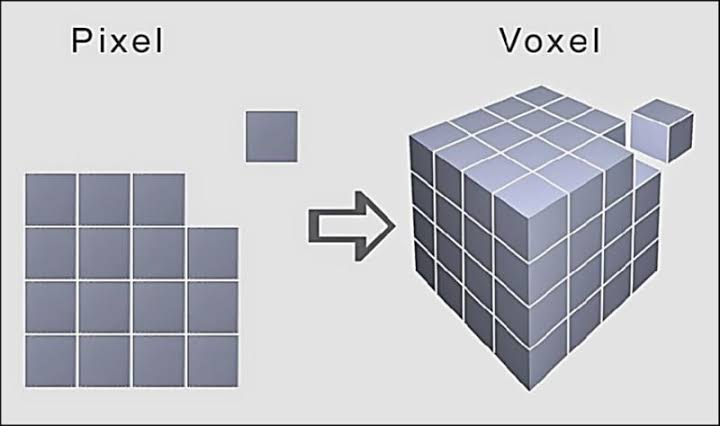

## DICOM frente a NIfTI

**DICOM** es un estándar clínico. Una adquisición suele ser una carpeta con muchos archivos; cada uno combina datos de píxel y numerosas etiquetas. Puede contener información identificable.

**NIfTI** guarda habitualmente un volumen 3D/4D en `.nii` o `.nii.gz` y una matriz `affine` que transforma índices de vóxel `(i, j, k)` a coordenadas físicas. Es común en análisis neurocientífico.

| Aspecto | DICOM | NIfTI |
|---|---|---|
| Organización | muchos objetos/instancias | uno o pocos archivos |
| Uso típico | adquisición y entorno clínico | análisis e investigación |
| Metadatos | muy ricos, a menudo sensibles | cabecera compacta + sidecars opcionales |
| Geometría | etiquetas por instancia/serie | `shape`, zooms y `affine` |

Convertir no equivale a anonimizar. Trabajen con copias desidentificadas y sigan el protocolo ético/institucional.


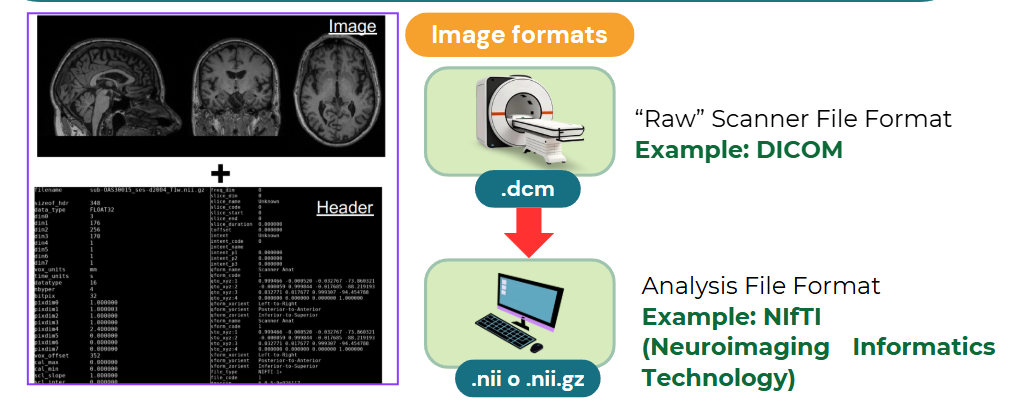

# 5. Una imagen DICOM de práctica y una serie real

`pydicom` incluye un pequeño corte CT de ejemplo. Sirve para aprender a relacionar etiquetas con píxeles sin buscar datos clínicos. Es **una sola instancia**, no una serie 3D, por lo que no sustituye el ejercicio de conversión volumétrica.


In [25]:
from pydicom import examples

dicom_demo = examples.ct
pixeles_crudos = dicom_demo.pixel_array.astype(np.float32)
pendiente = float(getattr(dicom_demo, "RescaleSlope", 1.0))
intercepto = float(getattr(dicom_demo, "RescaleIntercept", 0.0))
unidades_hu = pixeles_crudos * pendiente + intercepto

print("Modalidad:", dicom_demo.Modality)
print("shape:", pixeles_crudos.shape, "dtype almacenado:", dicom_demo.pixel_array.dtype)
print("PixelSpacing:", dicom_demo.PixelSpacing, "mm")
print("SliceThickness:", getattr(dicom_demo, "SliceThickness", "no disponible"), "mm")
print("RescaleSlope/Intercept:", pendiente, intercepto)


Modalidad: CT
shape: (128, 128) dtype almacenado: int16
PixelSpacing: [0.661468, 0.661468] mm
SliceThickness: 5.000000 mm
RescaleSlope/Intercept: 1.0 -1024.0


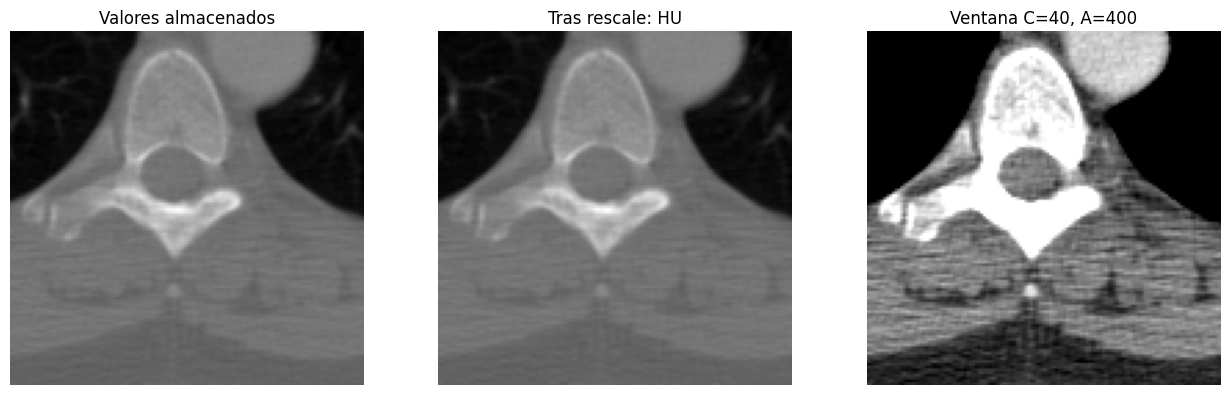

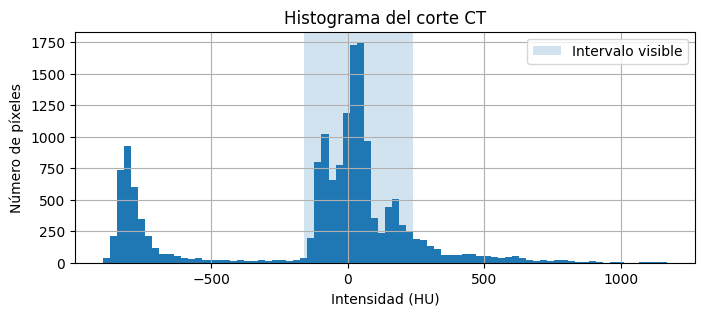

In [26]:
# En CT, window/level selecciona el intervalo visible; no cambia el archivo.
centro_ventana, ancho_ventana = 40, 400
vmin = centro_ventana - ancho_ventana / 2
vmax = centro_ventana + ancho_ventana / 2

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(pixeles_crudos, cmap="gray")
axes[0].set_title("Valores almacenados")
axes[1].imshow(unidades_hu, cmap="gray")
axes[1].set_title("Tras rescale: HU")
axes[2].imshow(unidades_hu, cmap="gray", vmin=vmin, vmax=vmax)
axes[2].set_title(f"Ventana C={centro_ventana}, A={ancho_ventana}")
for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(unidades_hu.ravel(), bins=80)
ax.axvspan(vmin, vmax, alpha=0.2, label="Intervalo visible")
ax.set(xlabel="Intensidad (HU)", ylabel="Número de píxeles", title="Histograma del corte CT")
ax.legend()
plt.show()


## Inspeccionar una serie DICOM propia

No mezclen series diferentes en una misma conversión. Etiquetas útiles:

- `SeriesInstanceUID`: identidad de la serie;
- `Modality`, `SeriesDescription`, `ProtocolName`;
- `Rows`, `Columns`, `PixelSpacing`, `SliceThickness`;
- `ImagePositionPatient`, `ImageOrientationPatient`;
- `InstanceNumber` (orientativo, no siempre suficiente para ordenar);
- campos de identificación del paciente: sensibles.

El siguiente código lee metadatos de un archivo sin cargar los píxeles (`stop_before_pixels=True`).


In [27]:
import pydicom

DICOM_DIR = DATA_DIR / "participante-01" / "dicom" / "T1w"
archivos_dicom = sorted(p for p in DICOM_DIR.rglob("*") if p.is_file()) if DICOM_DIR.exists() else []

if archivos_dicom:
    ds = pydicom.dcmread(archivos_dicom[0], stop_before_pixels=True, force=True)
    etiquetas = [
        "Modality", "SeriesDescription", "SeriesInstanceUID", "Rows", "Columns",
        "PixelSpacing", "SliceThickness", "ImagePositionPatient",
        "ImageOrientationPatient", "InstanceNumber",
    ]
    for etiqueta in etiquetas:
        print(f"{etiqueta:24s}: {getattr(ds, etiqueta, 'NO DISPONIBLE')}")
    print("Archivos encontrados:", len(archivos_dicom))
else:
    print(f"Agregue una serie DICOM desidentificada en: {DICOM_DIR.resolve()}")


Agregue una serie DICOM desidentificada en: /content/neuroco-manejo-datos/datos/participante-01/dicom/T1w


In [ ]:
# Auditoría rápida: ¿hay más de una serie en la carpeta?
from collections import Counter

conteo_series = Counter()
for archivo in archivos_dicom:
    try:
        cabecera = pydicom.dcmread(archivo, stop_before_pixels=True, force=True)
        uid = str(getattr(cabecera, "SeriesInstanceUID", "SIN_UID"))
        conteo_series[uid] += 1
    except Exception:
        pass

print("Número de SeriesInstanceUID:", len(conteo_series))
for uid, cantidad in conteo_series.most_common():
    print(cantidad, "instancias |", uid)


# 6. Convertir DICOM → NIfTI

## Opción recomendada: dcm2niix

`dcm2niix` maneja numerosos detalles de fabricantes, compresión, orientación y adquisiciones complejas. Instálenlo por separado y verifiquen que el comando `dcm2niix` esté disponible.

Parámetros usados abajo:

- `-z y`: comprimir a `.nii.gz`;
- `-b y`: crear sidecar JSON cuando sea posible;
- `-f ...`: patrón del nombre de salida;
- `-o`: carpeta de salida.

En datos reales revisen el informe completo del convertidor y todos los archivos producidos.


In [ ]:
NIFTI_DIR = OUTPUT_DIR / "nifti"
NIFTI_DIR.mkdir(parents=True, exist_ok=True)

ejecutable = shutil.which("dcm2niix")
if DICOM_DIR.exists() and ejecutable:
    comando = [
        ejecutable, "-z", "y", "-b", "y",
        "-f", "sub-01_T1w", "-o", str(NIFTI_DIR), str(DICOM_DIR),
    ]
    resultado = subprocess.run(comando, text=True, capture_output=True, check=False)
    print(resultado.stdout)
    if resultado.stderr:
        print("Mensajes del convertidor:\n", resultado.stderr)
    if resultado.returncode != 0:
        raise RuntimeError(f"dcm2niix terminó con código {resultado.returncode}")
elif not DICOM_DIR.exists():
    print("Conversión omitida: no existe la carpeta DICOM.")
else:
    print("Conversión omitida: dcm2niix no está instalado o no está en PATH.")


## Alternativa en Python: SimpleITK

Es útil para una serie 3D sencilla. Para adquisiciones complejas (difusión, fMRI, multieco, mosaicos), prefieran `dcm2niix`.

SimpleITK usa coordenadas físicas LPS, mientras muchas herramientas NIfTI describen orientación en términos RAS. La biblioteca escribe la geometría correspondiente; no reordenen ejes manualmente “a ojo”.


In [ ]:
import SimpleITK as sitk

salida_sitk = NIFTI_DIR / "sub-01_T1w_sitk.nii.gz"
if DICOM_DIR.exists():
    series_ids = sitk.ImageSeriesReader.GetGDCMSeriesIDs(str(DICOM_DIR))
    if not series_ids:
        print("SimpleITK no encontró series DICOM legibles.")
    else:
        if len(series_ids) > 1:
            print("Advertencia: hay varias series; se convertirá solo la primera:", series_ids)
        nombres = sitk.ImageSeriesReader.GetGDCMSeriesFileNames(str(DICOM_DIR), series_ids[0])
        lector = sitk.ImageSeriesReader()
        lector.SetFileNames(nombres)
        imagen = lector.Execute()
        sitk.WriteImage(imagen, str(salida_sitk), useCompression=True)
        print("Guardado:", salida_sitk.resolve())
        print("Tamaño xyz:", imagen.GetSize(), "espaciado mm:", imagen.GetSpacing())
else:
    print("Conversión SimpleITK omitida: falta la carpeta DICOM.")


# 7. Cargar, visualizar y verificar el NIfTI

Con NiBabel hay que distinguir:

- `img.shape`: número de vóxeles por eje;
- `img.header.get_zooms()`: tamaño de vóxel (y TR si es 4D);
- `img.affine`: índice de vóxel → coordenada física;
- `nib.aff2axcodes(img.affine)`: etiquetas de orientación aproximadas;
- `img.get_fdata()`: intensidades como array NumPy (puede consumir mucha RAM).

Para volúmenes grandes, eviten llamar `get_fdata()` repetidamente.


In [ ]:
import nibabel as nib

candidatos = sorted(NIFTI_DIR.glob("*.nii")) + sorted(NIFTI_DIR.glob("*.nii.gz"))
candidatos_reales = [p for p in candidatos if p.name != "fantoma_demo.nii.gz"]
candidatos = candidatos_reales or candidatos
if candidatos:
    ruta_nifti = candidatos[0]
    img = nib.load(ruta_nifti)
    volumen = img.get_fdata(dtype=np.float32)
    print("Archivo:", ruta_nifti.resolve())
else:
    # Fantoma 3D para practicar la estructura y la visualización.
    xx, yy, zz = np.ogrid[-1:1:96j, -1:1:112j, -1:1:80j]
    volumen = np.exp(-4 * (xx**2 + 0.8 * yy**2 + 1.2 * zz**2)).astype(np.float32)
    affine = np.diag([2.0, 2.0, 2.5, 1.0])
    img = nib.Nifti1Image(volumen, affine)
    ruta_nifti = NIFTI_DIR / "fantoma_demo.nii.gz"
    nib.save(img, ruta_nifti)
    print("No había NIfTI; se creó un fantoma:", ruta_nifti.resolve())

print("shape:", img.shape)
print("dtype en cabecera:", img.get_data_dtype())
print("zooms:", img.header.get_zooms())
print("orientación:", nib.aff2axcodes(img.affine))
print("affine:\n", img.affine)
resumen_array(volumen, "volumen NIfTI", ("i", "j", "k"), "intensidad")


In [ ]:
# Si es 4D, visualizar el primer volumen temporal sin perder el original.
volumen_3d = volumen[..., 0] if volumen.ndim == 4 else volumen

# Tres planos ortogonales pasando por el centro del array.
centro = tuple(s // 2 for s in volumen_3d.shape)
cortes = [
    (volumen_3d[centro[0], :, :].T, "Sagital"),
    (volumen_3d[:, centro[1], :].T, "Coronal"),
    (volumen_3d[:, :, centro[2]].T, "Axial"),
]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (corte, titulo) in zip(axes, cortes):
    ax.imshow(corte, cmap="gray", origin="lower")
    ax.set_title(titulo)
    ax.axis("off")
fig.suptitle("Cortes centrales (visualización en índices de vóxel)")
plt.tight_layout()
plt.show()


In [ ]:
# Un mosaico axial permite descubrir rápidamente cortes vacíos, truncamiento o artefactos.
indices_z = np.linspace(0, volumen_3d.shape[2] - 1, 12, dtype=int)
fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, z in zip(axes.flat, indices_z):
    ax.imshow(volumen_3d[:, :, z].T, cmap="gray", origin="lower")
    ax.set_title(f"z={z}")
    ax.axis("off")
fig.suptitle("Muestreo de cortes axiales a lo largo del volumen")
plt.tight_layout()
plt.show()


In [ ]:
# Distribución de intensidades y proyección de máxima intensidad (MIP).
valores = volumen_3d[np.isfinite(volumen_3d)]
p1, p99 = np.percentile(valores, [1, 99])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(valores, bins=100, range=(p1, p99))
axes[0].set(xlabel="Intensidad", ylabel="Número de vóxeles", title="Histograma entre percentiles 1–99")
axes[1].imshow(np.max(volumen_3d, axis=2).T, cmap="gray", origin="lower")
axes[1].set_title("Proyección de máxima intensidad (eje z)")
axes[1].axis("off")
plt.tight_layout()
plt.show()


In [ ]:
# Verificaciones mínimas posteriores a la conversión.
determinante = np.linalg.det(img.affine[:3, :3])
assert len(img.shape) in (3, 4), "Se esperaba un NIfTI 3D o 4D"
assert all(n > 1 for n in img.shape[:3]), "Algún eje espacial es degenerado"
assert np.isfinite(img.affine).all(), "La affine contiene valores no finitos"
assert not np.isclose(determinante, 0), "La affine no es invertible"
assert np.isfinite(volumen).all(), "El volumen contiene NaN o infinito"

print("✓ Dimensionalidad plausible")
print("✓ Affine finita e invertible; det =", determinante)
print("✓ Intensidades finitas")
print("Aún falta comparar visualmente con el DICOM y revisar los mensajes del convertidor.")


## Qué revisar después de convertir

1. ¿Se convirtió la serie correcta y completa?
2. ¿Las dimensiones y tamaños de vóxel concuerdan con el protocolo?
3. ¿La anatomía se ve completa, sin cortes invertidos, intercalados o deformados?
4. ¿La orientación reportada es plausible?
5. ¿Se conservaron sidecars JSON relevantes?
6. ¿Hay advertencias de `dcm2niix`?
7. ¿El NIfTI está desidentificado y almacenado de forma segura?

> La orientación izquierda/derecha es crítica. No la “corrijan” rotando el array hasta que se vea bien. Investiguen la geometría y comparen con marcadores o referencias confiables.


## Mini-reto 3: auditoría de imagen

Con una serie desidentificada:

1. Agrupe los archivos por `SeriesInstanceUID`.
2. Registre modalidad, descripción, número de instancias y espaciado.
3. Convierta una sola serie con `dcm2niix`.
4. Informe `shape`, `dtype`, zooms, orientación y `affine`.
5. Muestre cortes sagital, coronal y axial.
6. Anote cualquier advertencia y explique si el resultado es confiable.


# 8. Preparar los datos para un algoritmo

Un algoritmo no recibe “un EDF” o “un NIfTI” en abstracto: recibe arrays con una forma, tipo y escala definidos.

**EEG por épocas**

```text
Raw (canales × tiempo)
    → referencia/filtros documentados
    → segmentación
    → control de artefactos
    → X (épocas × canales × muestras)
    → características 2D o red neuronal 3D
```

**Imagen 3D**

```text
NIfTI (x × y × z)
    → orientación y registro
    → remuestreo a rejilla común
    → máscara/recorte
    → normalización aprendida sin mirar test
    → X (sujetos × canales × x × y × z)
```

La secuencia exacta depende de la pregunta científica. Cada transformación debe justificarse, parametrizarse y poder repetirse.


## 8.1 Ejemplo EEG: filtrar, segmentar y controlar artefactos

Este ejemplo usa el EEG sintético para que sea ejecutable. En datos reales, el filtro, la referencia, la longitud de época y el umbral deben definirse con el protocolo y validarse visualmente.


In [ ]:
raw_pre = raw_demo.copy().load_data()
raw_pre.set_eeg_reference("average", projection=False, verbose=False)
raw_pre.filter(l_freq=1.0, h_freq=40.0, picks="eeg", verbose=False)

# Comparar antes/después en tiempo y frecuencia.
antes = raw_demo.get_data()[0]
despues = raw_pre.get_data()[0]
f_antes, p_antes = signal.welch(antes, fs=sfreq, nperseg=int(2 * sfreq))
f_despues, p_despues = signal.welch(despues, fs=sfreq, nperseg=int(2 * sfreq))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
muestra = tiempo < 2
axes[0].plot(tiempo[muestra], antes[muestra] * 1e6, label="Crudo")
axes[0].plot(tiempo[muestra], despues[muestra] * 1e6, label="Procesado", alpha=0.8)
axes[0].set(xlabel="Tiempo (s)", ylabel="Amplitud (µV)", title="Dominio temporal")
axes[0].legend()
ver = (f_antes >= 0.5) & (f_antes <= 60)
axes[1].semilogy(f_antes[ver], p_antes[ver] * 1e12, label="Crudo")
axes[1].semilogy(f_despues[ver], p_despues[ver] * 1e12, label="Procesado")
axes[1].set(xlabel="Frecuencia (Hz)", ylabel="PSD (µV²/Hz)", title="Efecto del preprocesamiento")
axes[1].legend()
plt.tight_layout()
plt.show()


In [ ]:
# Ventanas de 2 s con 1 s de solapamiento.
epocas = mne.make_fixed_length_epochs(
    raw_pre, duration=2.0, overlap=1.0, preload=True, verbose=False
)
X_eeg = epocas.get_data().copy()  # épocas × canales × muestras

pico_a_pico = np.ptp(X_eeg, axis=-1).max(axis=1)  # peor canal de cada época
umbral = 150e-6
conservar = pico_a_pico < umbral
X_eeg_limpio = X_eeg[conservar].astype(np.float32)

print("X antes:", X_eeg.shape, X_eeg.dtype)
print("X después del umbral:", X_eeg_limpio.shape, X_eeg_limpio.dtype)
print("Épocas rechazadas:", (~conservar).sum())

fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(pico_a_pico * 1e6, bins=min(20, len(pico_a_pico)))
ax.axvline(umbral * 1e6, color="red", linestyle="--", label=f"Umbral: {umbral*1e6:.0f} µV")
ax.set(xlabel="Máximo pico a pico de la época (µV)", ylabel="Número de épocas", title="Control simple de artefactos")
ax.legend()
plt.show()


In [ ]:
# Ver todas las épocas de un canal ayuda a detectar deriva y valores atípicos.
t_epoca = epocas.times
fig, ax = plt.subplots(figsize=(10, 4))
for i, epoca in enumerate(X_eeg[:, 0, :]):
    ax.plot(t_epoca, epoca * 1e6, alpha=0.35, color="tab:blue" if conservar[i] else "tab:red")
ax.set(xlabel="Tiempo dentro de la época (s)", ylabel="Fz (µV)", title="Superposición de épocas; rojo = rechazo")
plt.show()


## 8.2 Dos representaciones para aprendizaje automático

- **Modelos clásicos:** una matriz 2D `X` = ejemplos × características. Podemos resumir cada canal con potencia por banda, entropía, conectividad u otras características justificadas.
- **Red temporal o convolucional:** conservar `X` = épocas × canales × muestras.

No hay una representación universalmente mejor. Una característica fácil de interpretar suele ser un buen punto de partida.


In [ ]:
def caracteristicas_bandas(X, fs, bandas):
    # Devuelve log-potencia: épocas × (canales · bandas).
    f, p = signal.welch(X, fs=fs, nperseg=min(X.shape[-1], int(2 * fs)), axis=-1)
    salida = []
    for f0, f1 in bandas.values():
        mascara = (f >= f0) & (f < f1)
        salida.append(np.trapz(p[..., mascara], f[mascara], axis=-1))
    potencia = np.stack(salida, axis=-1)  # épocas × canales × bandas
    return np.log10(potencia + np.finfo(float).eps).reshape(len(X), -1)

bandas_ml = {"theta": (4, 8), "alfa": (8, 13), "beta": (13, 30)}
X_features = caracteristicas_bandas(X_eeg_limpio, epocas.info["sfreq"], bandas_ml)
nombres_features = [f"{canal}_{banda}" for canal in epocas.ch_names for banda in bandas_ml]

print("Entrada para red:", X_eeg_limpio.shape, "= épocas × canales × muestras")
print("Entrada clásica:", X_features.shape, "= épocas × características")
print("Características:", nombres_features)

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(X_features, aspect="auto", cmap="magma")
ax.set(xlabel="Característica", ylabel="Época", title="Matriz que recibe un modelo clásico")
ax.set_xticks(range(len(nombres_features)), nombres_features, rotation=45, ha="right")
fig.colorbar(im, ax=ax, label="log10(potencia)")
plt.tight_layout()
plt.show()


## 8.3 Separar antes de aprender transformaciones

El conjunto de prueba simula datos verdaderamente nuevos. Por eso:

1. separen por **participante** cuando haya varias épocas por persona;
2. ajusten escaladores, imputadores, PCA y selección de características solo con entrenamiento;
3. apliquen al test los parámetros aprendidos en entrenamiento;
4. mantengan el test fuera de decisiones de preprocesamiento e hiperparámetros.

El ejemplo siguiente enseña la mecánica con etiquetas artificiales. Su exactitud **no tiene significado científico**.


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

if len(X_features) >= 4:
    y_demo = np.arange(len(X_features)) % 2  # SOLO para demostrar la interfaz X/y.
    X_train, X_test, y_train, y_test = train_test_split(
        X_features, y_demo, test_size=0.33, stratify=y_demo, random_state=42
    )
    modelo = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000))
    modelo.fit(X_train, y_train)  # StandardScaler aprende únicamente de train.
    pred = modelo.predict(X_test)

    print("train:", X_train.shape, "test:", X_test.shape)
    print(classification_report(y_test, pred, zero_division=0))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, cmap="Blues")
    plt.title("Matriz de confusión — etiquetas artificiales")
    plt.show()
else:
    print("No hay suficientes épocas para la demostración del clasificador.")


En un estudio real, usen grupos de participante, por ejemplo:

```python
from sklearn.model_selection import GroupKFold, cross_validate

cv = GroupKFold(n_splits=5)
resultados = cross_validate(modelo, X, y, groups=id_participante, cv=cv)
```

Si épocas del mismo participante aparecen en entrenamiento y prueba, el modelo puede reconocer a la persona en vez del fenómeno de interés.


## 8.4 Preparar un volumen para una red

Antes de apilar sujetos, todos deben compartir orientación, espacio, resolución y dimensiones. El registro y el remuestreo son decisiones científicas: al remuestrear imágenes continuas suele usarse interpolación lineal o B-spline; para máscaras de etiquetas, vecino más cercano.

El ejemplo reorienta a una convención canónica y aplica un escalado robusto por percentiles. En un proyecto real deben decidir si la normalización será por volumen, por modalidad o aprendida únicamente en entrenamiento.


In [ ]:
img_canonica = nib.as_closest_canonical(img)
vol_canonico = img_canonica.get_fdata(dtype=np.float32)
vol_canonico = vol_canonico[..., 0] if vol_canonico.ndim == 4 else vol_canonico

finitos = np.isfinite(vol_canonico)
p_bajo, p_alto = np.percentile(vol_canonico[finitos], [1, 99])
vol_norm = np.clip((vol_canonico - p_bajo) / (p_alto - p_bajo + 1e-8), 0, 1)
vol_norm[~finitos] = 0

# Convenciones frecuentes:
X_pytorch = vol_norm[None, None, ...].astype(np.float32)   # lote × canal × x × y × z
X_keras = vol_norm[None, ..., None].astype(np.float32)    # lote × x × y × z × canal

print("Orientación canónica:", nib.aff2axcodes(img_canonica.affine))
print("PyTorch:", X_pytorch.shape, X_pytorch.dtype)
print("Keras/TensorFlow:", X_keras.shape, X_keras.dtype)


In [ ]:
z = vol_canonico.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].imshow(vol_canonico[:, :, z].T, cmap="gray", origin="lower")
axes[0].set_title("Antes")
axes[1].imshow(vol_norm[:, :, z].T, cmap="gray", origin="lower", vmin=0, vmax=1)
axes[1].set_title("Después: [0, 1]")
axes[2].hist(vol_norm.ravel(), bins=80)
axes[2].set(xlabel="Intensidad normalizada", ylabel="Vóxeles", title="Distribución final")
for ax in axes[:2]:
    ax.axis("off")
plt.tight_layout()
plt.show()


### Lista de comprobación antes de entrenar

- `X` y `y` tienen el mismo número de ejemplos.
- `X.dtype` es apropiado, normalmente `float32`; las etiquetas suelen ser enteras.
- No quedan NaN o infinitos sin una estrategia explícita.
- Los ejes y unidades están documentados.
- El particionado se hizo por participante/sesión antes de aprender transformaciones.
- No hay duplicados ni ventanas solapadas repartidas entre train y test.
- Las clases y participantes están contabilizados por partición.
- El baseline simple se compara con azar y con una estrategia ingenua.
- Se guardan semilla, versiones, parámetros, métricas y predicciones.
- La métrica corresponde a la pregunta y al desbalance de clases.


# 9. Un flujo reproducible para cualquier dato

**1. Identificar** → formato, modalidad, participante, sesión y tarea.  
**2. Preservar** → no modificar el original; trabajar sobre una copia controlada.  
**3. Inspeccionar** → metadatos, forma, tipo, ejes, unidades, faltantes y rangos.  
**4. Visualizar crudo** → una vista temporal/espacial y una distribución o espectro.  
**5. Convertir o transformar** → con parámetros explícitos y registro de versiones.  
**6. Verificar** → comparar antes/después; revisar geometría, duración y conteos.  
**7. Documentar** → decisiones, advertencias, nombres y procedencia.  
**8. Analizar** → solo cuando el dato sea interpretable y la calidad esté registrada.

Una organización tipo BIDS ayuda a mantener nombres consistentes, por ejemplo:

```text
proyecto/
├── datos_originales/        # acceso restringido, no modificar
├── datos/
│   └── sub-01/
│       ├── eeg/
│       └── anat/
├── resultados/
├── notebooks/
└── README.md
```


# 10. Actividad integradora

En parejas, preparen una ficha técnica de un EEG y una imagen:

- procedencia y formato;
- `shape`, `dtype`, ejes y unidades;
- metadatos esenciales;
- dos visualizaciones pertinentes;
- transformación o conversión realizada;
- controles de calidad;
- riesgos, supuestos y dudas pendientes.

**Criterio de logro:** otra persona debe poder entender la estructura, repetir la carga y juzgar si el dato es apto para análisis sin preguntarles qué significa cada eje.


## Cierre: preguntas de comprobación

1. ¿Por qué `shape` no basta para interpretar un array?
2. Si hay 30 000 muestras a 250 Hz, ¿cuál es la duración?
3. ¿Por qué MNE puede mostrar µV aunque almacene V?
4. ¿Qué diferencia hay entre tamaño del array y tamaño de vóxel?
5. ¿Qué función cumple la `affine` de un NIfTI?
6. ¿Por qué ordenar DICOM solo por nombre de archivo puede fallar?
7. ¿Convertir DICOM a NIfTI anonimiza automáticamente el estudio?
8. ¿Qué verificarían antes de iniciar un análisis estadístico?

### Recursos

- [NumPy: fundamentos de arrays](https://numpy.org/doc/stable/user/absolute_beginners.html)
- [MNE-Python: lectura de datos](https://mne.tools/stable/auto_tutorials/io/20_reading_eeg_data.html)
- [NiBabel: imágenes NIfTI](https://nipy.org/nibabel/nifti_images.html)
- [pydicom](https://pydicom.github.io/pydicom/stable/)
- [dcm2niix](https://github.com/rordenlab/dcm2niix)
- [BIDS](https://bids.neuroimaging.io/)
- [EEGBCI en PhysioNet](https://physionet.org/content/eegmmidb/1.0.0/)
- [scikit-learn: evitar fuga de datos](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage)
